# Klasifikasi Berita Menggunakan Skip-gram dan Naive Bayes

Notebook ini mengimplementasikan klasifikasi teks berita Detik.com kategori **finance** dan **sport** menggunakan representasi kata **Word2Vec Skip-gram (Scratch)** dan algoritma klasifikasi **Gaussian Naive Bayes** secara bertahap.

### Alur Proses:
Dataset berita &rarr; Preprocessing &rarr; Train-Test Split &rarr; Tokenisasi &rarr; Pasangan Target-Context &rarr; Vocabulary &rarr; Skip-gram Training &rarr; Word Embedding &rarr; Vektor Berita &rarr; Gaussian Naive Bayes &rarr; Prediksi &rarr; Evaluasi

### Ketentuan Preprocessing:
Preprocessing pada tugas ini **hanya menghilangkan tanda baca**.
Tidak dilakukan:
- Stopword removal
- Stemming
- Normalisasi kata
- Translasi bahasa asing
- TF-IDF
- ICSDF
- PCA

## 1. Install Library
Tahap ini digunakan untuk menginstal paket atau library Python yang dibutuhkan dalam pemrosesan data, machine learning, visualisasi, dan ekspor file Excel.

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl

## 2. Import Library
Tahap ini mengimpor seluruh library yang diperlukan untuk manipulasi data (pandas, numpy), pembersihan string (re, unicodedata), pemodelan klasifikasi dan evaluasi (scikit-learn), serta visualisasi (matplotlib, seaborn).

In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from IPython.display import display


## 3. Membaca Dataset
Dataset yang digunakan adalah `dataset_detik.csv` yang berisi kumpulan berita dari Detik.com dengan kategori sport dan finance.

In [3]:
FILE_DATASET = "dataset_detik.csv"
df = pd.read_csv(FILE_DATASET)

print("Jumlah data :", len(df))
print("Nama kolom  :", df.columns.tolist())
display(df.head())

Jumlah data : 200
Nama kolom  : ['id', 'isi_berita', 'label', 'url']


,id,isi_berita,label,url
0,SP001,"FIA Rallycross World Cup Hadir di Ancol, Ini K...",sport,https://sport.detik.com/sportstyle/d-8686174/f...
1,SP002,Ini Kunci Desak Made Rita Raih Emas Asian Game...,sport,https://sport.detik.com/sport-lain/d-8686789/i...
2,SP003,Desak Made Raih Emas Panjat Tebing Asian Games...,sport,https://sport.detik.com/fotosport/d-8686774/de...
3,SP004,Profil Desak Made Peraih Emas Keempat RI: Kena...,sport,https://sport.detik.com/sport-lain/d-8686722/p...
4,SP005,"Gacor di Asian Games, Leo/Daniel Kini Bidik Tu...",sport,https://sport.detik.com/raket/d-8686185/gacor-...


## 4. Pemeriksaan Dataset
Sebelum preprocessing, dataset diperiksa untuk mengetahui tipe data, memastikan tidak ada nilai null (kosong), dan melihat persebaran data pada tiap kategori.

In [4]:
print("Informasi dataset:")
df.info()

print("\nJumlah nilai kosong:")
print(df[["id", "isi_berita", "label"]].isnull().sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    object
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB

Jumlah nilai kosong:
id            0
isi_berita    0
label         0
dtype: int64

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


## 5. Label Numerik
Mengubah label teks kategori berita menjadi bentuk numerik biner: `finance = 0` dan `sport = 1` agar dapat digunakan dalam pemodelan Naive Bayes.

In [5]:
df["label_num"] = df["label"].map({
    "finance": 0,
    "sport": 1
})

print("Mapping label:")
print("finance = 0")
print("sport = 1")
print("\nDistribusi label numerik:")
print(df["label_num"].value_counts().sort_index())
display(df[["id", "label", "label_num"]].head())

Mapping label:
finance = 0
sport = 1

Distribusi label numerik:
label_num
0    100
1    100
Name: count, dtype: int64


,id,label,label_num
0,SP001,sport,1
1,SP002,sport,1
2,SP003,sport,1
3,SP004,sport,1
4,SP005,sport,1


## 6. Jumlah Kata Sebelum Preprocessing
Menghitung jumlah total kata dan statistik deskriptif panjang teks pada seluruh dokumen berita sebelum dilakukan pembersihan tanda baca.

In [6]:
df["jumlah_kata_asli"] = df["isi_berita"].astype(str).apply(lambda x: len(x.split()))

print("Total seluruh kata:", df["jumlah_kata_asli"].sum())
print("\nStatistik jumlah kata:")
print(df["jumlah_kata_asli"].describe())
display(df[["id", "label", "jumlah_kata_asli"]].head())

Total seluruh kata: 76101

Statistik jumlah kata:
count    200.000000
mean     380.505000
std      146.723512
min       59.000000
25%      284.750000
50%      368.000000
75%      474.500000
max      884.000000
Name: jumlah_kata_asli, dtype: float64


,id,label,jumlah_kata_asli
0,SP001,sport,484
1,SP002,sport,483
2,SP003,sport,245
3,SP004,sport,436
4,SP005,sport,361


## 7. Preprocessing
Preprocessing dilakukan dengan aturan: **HANYA menghapus tanda baca** (punctuation) menggunakan kategori Unicode 'P' dan merapikan whitespace. Tidak menggunakan stemming, stopword, translasi, TF-IDF, ICSDF, maupun PCA.

In [7]:
def remove_punctuation(text):
    text = str(text)
    # Menghapus karakter kategori Punctuation (P)
    text = "".join(char for char in text if not unicodedata.category(char).startswith("P"))
    # Menghapus whitespace berlebih
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["berita_clean"] = df["isi_berita"].apply(remove_punctuation)
display(df[["id", "isi_berita", "berita_clean", "label"]].head())

,id,isi_berita,berita_clean,label
0,SP001,"FIA Rallycross World Cup Hadir di Ancol, Ini K...",FIA Rallycross World Cup Hadir di Ancol Ini Ke...,sport
1,SP002,Ini Kunci Desak Made Rita Raih Emas Asian Game...,Ini Kunci Desak Made Rita Raih Emas Asian Game...,sport
2,SP003,Desak Made Raih Emas Panjat Tebing Asian Games...,Desak Made Raih Emas Panjat Tebing Asian Games...,sport
3,SP004,Profil Desak Made Peraih Emas Keempat RI: Kena...,Profil Desak Made Peraih Emas Keempat RI Kenal...,sport
4,SP005,"Gacor di Asian Games, Leo/Daniel Kini Bidik Tu...",Gacor di Asian Games LeoDaniel Kini Bidik Tur ...,sport


## 8. Pemeriksaan Hasil
Menampilkan sampel teks berita sebelum dan sesudah penghapusan tanda baca untuk memverifikasi kebenaran hasil preprocessing.

In [8]:
for i in range(min(5, len(df))):
    print(f"DATA {i + 1}")
    print("Sebelum:")
    print(df.loc[i, "isi_berita"][:250] + "...")
    print("\nSesudah:")
    print(df.loc[i, "berita_clean"][:250] + "...")
    print("-" * 80)

DATA 1
Sebelum:
FIA Rallycross World Cup Hadir di Ancol, Ini Keseruan yang Bisa Disaksikan Tim detikEvent - Sport Rabu, 30 Sep 2026 21:50 WIB ... Tautan telah disalin Jakarta - Pecinta rallycross punya agenda baru yang bisa masuk kalender akhir tahun. FIA Rallycross...

Sesudah:
FIA Rallycross World Cup Hadir di Ancol Ini Keseruan yang Bisa Disaksikan Tim detikEvent Sport Rabu 30 Sep 2026 2150 WIB Tautan telah disalin Jakarta Pecinta rallycross punya agenda baru yang bisa masuk kalender akhir tahun FIA Rallycross World Cup I...
--------------------------------------------------------------------------------
DATA 2
Sebelum:
Ini Kunci Desak Made Rita Raih Emas Asian Games 2026 Mercy Raya - detikSport Rabu, 30 Sep 2026 21:20 WIB Jakarta - Atlet panjat tebing Desak Made Rita Kusuma Dewi sukses meraih emas Asian Games 2026 . Lantas apa kunci kemenangannya? Turun di nomor sp...

Sesudah:
Ini Kunci Desak Made Rita Raih Emas Asian Games 2026 Mercy Raya detikSport Rabu 30 Sep 2026 2120 WIB Jaka

## 9. Jumlah Kata Setelah Preprocessing
Menghitung jumlah kata setelah tanda baca dihilangkan dan membandingkannya dengan jumlah kata awal.

In [9]:
df["jumlah_kata_clean"] = df["berita_clean"].astype(str).apply(lambda x: len(x.split()))

print("Total kata sebelum preprocessing:", df["jumlah_kata_asli"].sum())
print("Total kata setelah preprocessing:", df["jumlah_kata_clean"].sum())
display(df[["id", "jumlah_kata_asli", "jumlah_kata_clean", "label"]].head())

Total kata sebelum preprocessing: 76101
Total kata setelah preprocessing: 75273


,id,jumlah_kata_asli,jumlah_kata_clean,label
0,SP001,484,479,sport
1,SP002,483,480,sport
2,SP003,245,242,sport
3,SP004,436,434,sport
4,SP005,361,356,sport


## 10. Train-Test Split
Membagi dataset menjadi 160 data training dan 40 data testing (rasio 80:20) dengan stratifikasi agar seimbang (80 training dan 20 testing per kategori).

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["berita_clean"], df["label_num"], test_size=40,
    random_state=42, stratify=df["label_num"]
)
X_train_text = X_train_text.sort_index()
X_test_text = X_test_text.sort_index()
y_train = y_train.loc[X_train_text.index]
y_test = y_test.loc[X_test_text.index]
print("Jumlah training :", len(X_train_text))
print("Jumlah testing  :", len(X_test_text))
print("Distribusi TRAINING:")
print(y_train.value_counts().sort_index())
print("Distribusi TESTING:")
print(y_test.value_counts().sort_index())


Jumlah training : 160
Jumlah testing  : 40
Distribusi TRAINING:
label_num
0    80
1    80
Name: count, dtype: int64
Distribusi TESTING:
label_num
0    20
1    20
Name: count, dtype: int64


## 11. Tokenisasi
Setiap dokumen berita yang telah dibersihkan dipecah menjadi kumpulan kata (tokens) menggunakan fungsi `split()`.

In [11]:
train_sentences = [text.split() for text in X_train_text]
test_sentences = [text.split() for text in X_test_text]

print("Contoh tokenisasi TRAINING (3 dokumen pertama):")
for i in range(min(3, len(train_sentences))):
    print(f"{i + 1}.", train_sentences[i][:12], "...")

print("\nContoh tokenisasi TESTING (3 dokumen pertama):")
for i in range(min(3, len(test_sentences))):
    print(f"{i + 1}.", test_sentences[i][:12], "...")

Contoh tokenisasi TRAINING (3 dokumen pertama):
1. ['FIA', 'Rallycross', 'World', 'Cup', 'Hadir', 'di', 'Ancol', 'Ini', 'Keseruan', 'yang', 'Bisa', 'Disaksikan'] ...
2. ['Ini', 'Kunci', 'Desak', 'Made', 'Rita', 'Raih', 'Emas', 'Asian', 'Games', '2026', 'Mercy', 'Raya'] ...
3. ['Desak', 'Made', 'Raih', 'Emas', 'Panjat', 'Tebing', 'Asian', 'Games', '2026', 'Rengga', 'Sancaya', 'detikSport'] ...

Contoh tokenisasi TESTING (3 dokumen pertama):
1. ['Gacor', 'di', 'Asian', 'Games', 'LeoDaniel', 'Kini', 'Bidik', 'Tur', 'Eropa', 'Mercy', 'Raya', 'detikSport'] ...
2. ['Panjat', 'Tebing', 'Buru', 'Medali', 'Yenni', 'Wahid', 'Aditya', 'atau', 'Veddriq', 'yang', 'Penting', 'Emas'] ...
3. ['Mau', 'Nonton', 'FIA', 'Rallycross', 'World', 'Cup', 'Indonesia', 'Ini', 'Cara', 'Pilih', 'Spotnya', 'Tim'] ...


## 12. Target-Context
Membentuk pasangan (target word, context word) menggunakan sliding window sebesar 1 (`WINDOW_SIZE = 1`). Artinya, model melihat 1 kata di sebelah kiri dan 1 kata di sebelah kanan kata target.

In [12]:
WINDOW_SIZE = 1
training_pairs = []

for sentence in train_sentences:
    for i, target_word in enumerate(sentence):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(sentence), i + WINDOW_SIZE + 1)
        for j in range(start, end):
            if i != j:
                context_word = sentence[j]
                training_pairs.append((target_word, context_word))

print("Jumlah pasangan target-context:", len(training_pairs))
print("\n20 pasangan pertama:")
for pair in training_pairs[:20]:
    print(pair[0], "→", pair[1])

Jumlah pasangan target-context: 121246

20 pasangan pertama:
FIA → Rallycross
Rallycross → FIA
Rallycross → World
World → Rallycross
World → Cup
Cup → World
Cup → Hadir
Hadir → Cup
Hadir → di
di → Hadir
di → Ancol
Ancol → di
Ancol → Ini
Ini → Ancol
Ini → Keseruan
Keseruan → Ini
Keseruan → yang
yang → Keseruan
yang → Bisa
Bisa → yang


## 13. Vocabulary
Membuat daftar kosakata (vocabulary) unik dari data training, serta menyusun dictionary pemetaan kata ke indeks numerik (`word_to_index`) dan indeks ke kata (`index_to_word`).

In [13]:
vocabulary = sorted({word for sentence in train_sentences for word in sentence})
word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for word, i in word_to_index.items()}
VOCAB_SIZE = len(vocabulary)

print("Jumlah vocabulary:", VOCAB_SIZE)
print("\nContoh vocabulary (30 kata pertama):")
for word in vocabulary[:30]:
    print(word, "→", word_to_index[word])

Jumlah vocabulary: 9014

Contoh vocabulary (30 kata pertama):
+ → 0
+10742s → 1
+11890s → 2
+12976s → 3
+19574s → 4
+2 → 5
+3 → 6
+31203s → 7
+37605s → 8
+40320s → 9
0 → 10
00 → 11
0001 → 12
0002 → 13
0004 → 14
0045 → 15
006 → 16
009 → 17
01 → 18
0105 → 19
0113 → 20
0145 → 21
017 → 22
019 → 23
01s → 24
02 → 25
020 → 26
0215 → 27
026 → 28
027 → 29


## 14. Parameter Skip-gram
Menentukan parameter model Skip-gram: dimensi vektor (`VECTOR_SIZE = 50`), ukuran window (`WINDOW_SIZE = 1`), learning rate (`LEARNING_RATE = 0.025`), dan jumlah epoch pelatihan (`EPOCHS = 5`).

In [14]:
VECTOR_SIZE = 50
WINDOW_SIZE = 5
MIN_COUNT = 1
EPOCHS = 20
SG = 1
SEED = 42
print("Vector size   :", VECTOR_SIZE)
print("Window size   :", WINDOW_SIZE)
print("Min count     :", MIN_COUNT)
print("Epoch         :", EPOCHS)
print("sg            :", SG)


Vector size   : 50
Window size   : 5
Min count     : 1
Epoch         : 20
sg            : 1


## 15. Softmax
Mendefinisikan fungsi aktivasi Softmax numerik stabil untuk mengubah skor output menjadi probabilitas distribusi kata konteks pada vocabulary.

In [15]:
def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

## 16. Inisialisasi Bobot
Menginisialisasi dua matriks bobot:
- $W_1$ berukuran $(V \times D)$ sebagai representasi embedding kata
- $W_2$ berukuran $(D \times V)$ sebagai bobot output konteks

In [16]:
word2vec_model = Word2Vec(
    sentences=train_sentences, vector_size=VECTOR_SIZE, window=WINDOW_SIZE,
    min_count=MIN_COUNT, workers=1, sg=SG, epochs=EPOCHS, seed=SEED
)
vocabulary = word2vec_model.wv.index_to_key
word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}
VOCAB_SIZE = len(vocabulary)
word_embeddings = word2vec_model.wv.vectors
print("Jumlah vocabulary:", VOCAB_SIZE)
print("Shape word embedding:", word_embeddings.shape)
print("Contoh kata:", vocabulary[:10])


Jumlah vocabulary: 9014
Shape word embedding: (9014, 50)
Contoh kata: ['di', 'yang', 'dan', '2026', 'ini', 'dengan', 'juga', 'Indonesia', 'untuk', 'dari']


## 17. Training Skip-gram
Melatih model Skip-gram dengan melakukan forward pass, menghitung probabilitas softmax, cross-entropy loss, error output, gradien bobot, dan pembaruan bobot $W_1$ dan $W_2$ menggunakan stochastic gradient descent.

In [17]:
# Training manual lama dinonaktifkan; model utama menggunakan gensim Word2Vec sg=1.


## 18. Word Embedding
Setelah pelatihan, matriks $W_1$ diambil sebagai representasi word embedding. Setiap baris mewakili representasi vektor 50-dimensi dari satu kata dalam vocabulary.

In [18]:
print("Training selesai menggunakan Word2Vec Skip-gram dengan sg=1.")


Training selesai menggunakan Word2Vec Skip-gram dengan sg=1.


## 19. Vektor Kata
Melihat representasi vektor numerik untuk setiap kata dan menyusunnya ke dalam tabel DataFrame.

In [19]:
embedding_rows = []
for word in vocabulary:
    idx = word_to_index[word]
    vector = word_embeddings[idx]
    row = {"Kata": word}
    for i, val in enumerate(vector, 1):
        row[f"Vektor_{i}"] = val
    embedding_rows.append(row)

df_word_embedding = pd.DataFrame(embedding_rows)
display(df_word_embedding.head())

kata_contoh = vocabulary[0]
idx = word_to_index[kata_contoh]
print("Kata           :", kata_contoh)
print("Vektor         :", word_embeddings[idx][:5], "...")
print("Dimensi vektor :", len(word_embeddings[idx]))

,Kata,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,...,Vektor_41,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50
0,di,-0.099263,-0.141249,0.199935,0.664613,0.708077,-0.367164,-0.430826,0.525737,-1.387160,...,-0.434356,0.453902,-0.623220,-0.044667,-0.508857,0.773297,0.000318,0.905499,0.234969,0.812050
1,yang,-0.323264,-0.379624,-0.047195,-0.081294,-0.161965,-0.850618,-0.002654,-0.144003,0.051500,...,-0.163915,0.030712,-0.113805,-0.514476,0.523793,-0.143763,-1.171770,0.615591,0.261206,-0.105105
2,dan,0.186441,-0.811479,0.069833,-0.587294,-0.131817,-0.000211,0.054138,-0.484318,-0.151844,...,0.725443,0.150337,-0.044218,0.181996,0.338357,1.085452,-0.574293,0.252145,0.536208,-0.118975
3,2026,0.096545,-0.927738,0.613016,-0.583833,-0.008066,-0.334610,-0.020547,0.518112,-0.237027,...,0.912824,0.117443,0.072207,0.052766,1.155042,-0.837508,0.410955,0.387480,0.451552,-0.086779
4,ini,-0.634311,-0.034014,0.307501,-0.062664,-0.428335,-1.083312,-0.211620,0.504554,-0.219280,...,-0.000016,0.533182,-0.778035,-0.391246,0.062033,-0.510009,-0.162295,0.540730,0.184141,-0.860430


Kata           : di
Vektor         : [-0.09926326 -0.14124893  0.19993491  0.66461337  0.708077  ] ...
Dimensi vektor : 50


## 20. Vektor Berita
Setiap dokumen berita direpresentasikan menjadi satu vektor 50-dimensi dengan cara menghitung rata-rata vektor dari seluruh kata yang terkandung di dalam berita tersebut.

In [20]:
def document_vector(tokens, word_to_index, embeddings, vector_size):
    vectors = [embeddings[word_to_index[word]] for word in tokens if word in word_to_index]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_vectors = np.vstack([document_vector(tokens, word_to_index, word_embeddings, VECTOR_SIZE) for tokens in train_sentences])
X_test_vectors = np.vstack([document_vector(tokens, word_to_index, word_embeddings, VECTOR_SIZE) for tokens in test_sentences])
print("Shape X_train_vectors:", X_train_vectors.shape)
print("Shape X_test_vectors :", X_test_vectors.shape)
print("Dokumen train dengan vector nol:", np.sum(np.all(X_train_vectors == 0, axis=1)))
print("Dokumen test dengan vector nol :", np.sum(np.all(X_test_vectors == 0, axis=1)))


Shape X_train_vectors: (160, 50)
Shape X_test_vectors : (40, 50)
Dokumen train dengan vector nol: 0
Dokumen test dengan vector nol : 0


## 21. Dataset Vektor Training
Menyusun matriks vektor berita training menjadi DataFrame pandas berisikan 50 fitur kolom vektor dan 1 kolom label kelas.

In [21]:
vector_columns = [f"Vektor_{i}" for i in range(1, VECTOR_SIZE + 1)]
df_train_vectors = pd.DataFrame(X_train_vectors, columns=vector_columns)
df_train_vectors["label"] = y_train.reset_index(drop=True)

print("Shape training:", df_train_vectors.shape)
display(df_train_vectors.head())

Shape training: (160, 51)


,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,Vektor_10,...,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50,label
0,-0.269856,-0.420116,0.184875,-0.306871,0.094874,-0.335325,-0.133049,0.007426,-0.482141,-0.004090,...,0.002213,-0.024011,-0.104238,0.239711,0.237804,-0.310157,0.292435,0.273424,-0.252013,1
1,-0.354025,-0.675808,0.033729,-0.412585,0.136013,-0.460620,-0.183539,-0.117129,-0.424647,0.055479,...,-0.105497,0.076911,0.023952,0.086845,0.244459,-0.302086,0.539845,0.167781,-0.199904,1
2,-0.232752,-0.968077,0.178490,-0.426730,0.271027,-0.488201,-0.041677,-0.143242,-0.437237,0.056393,...,-0.158868,0.030960,0.076457,-0.024974,0.224191,-0.342156,0.342168,0.195798,0.042524,1
3,-0.281952,-0.704147,0.038127,-0.401299,0.167824,-0.450003,-0.186872,-0.075846,-0.430338,0.012959,...,-0.112047,0.023737,0.049976,0.050325,0.213027,-0.232690,0.539817,0.277538,-0.086609,1
4,-0.284475,-0.948836,0.104581,-0.365952,0.234393,-0.433433,-0.119693,0.005189,-0.458007,0.000846,...,-0.101088,0.115330,0.089319,-0.004240,0.167056,-0.270460,0.568372,0.316150,0.002003,1


## 22. Dataset Vektor Testing
Menyusun matriks vektor berita testing menjadi DataFrame pandas berisikan 50 fitur kolom vektor dan 1 kolom label kelas, lalu menyimpan dataset vektor training dan testing ke file Excel.

In [22]:
df_test_vectors = pd.DataFrame(X_test_vectors, columns=vector_columns)
df_test_vectors["label"] = y_test.reset_index(drop=True)

print("Shape testing:", df_test_vectors.shape)
display(df_test_vectors.head())

df_train_vectors.to_excel("data_skipgram_training.xlsx", index=False)
df_test_vectors.to_excel("data_skipgram_testing.xlsx", index=False)
print("Data vektor berhasil disimpan:")
print("- data_skipgram_training.xlsx")
print("- data_skipgram_testing.xlsx")

Shape testing: (40, 51)


,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,Vektor_10,...,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50,label
0,-0.437679,-0.666985,0.110861,-0.395533,0.103905,-0.466625,-0.222147,-0.055495,-0.449855,-0.002385,...,0.047614,0.124957,-0.025178,0.174631,0.205197,-0.246588,0.517212,0.205884,-0.282252,1
1,-0.260740,-0.742963,0.083989,-0.470057,0.159291,-0.438490,-0.165997,-0.106252,-0.428255,0.008422,...,-0.117232,0.042878,0.050112,0.069936,0.250105,-0.307170,0.463471,0.238592,-0.127593,1
2,-0.285197,-0.445581,0.165936,-0.277210,0.071359,-0.325817,-0.115009,-0.005746,-0.466328,-0.006704,...,0.048757,-0.002947,-0.136552,0.233101,0.292908,-0.317445,0.324331,0.239147,-0.255465,1
3,-0.380733,-0.757360,0.201726,-0.385642,0.140909,-0.502010,-0.103976,-0.072674,-0.458338,0.003630,...,0.017353,0.089651,0.084121,0.090219,0.233156,-0.219408,0.570106,0.093451,-0.143139,1
4,-0.493980,-0.906187,0.339430,-0.303775,0.143005,-0.479667,-0.109783,-0.197757,-0.429716,0.058069,...,0.040321,0.091173,0.069634,0.161154,0.229467,-0.335145,0.352056,-0.023346,-0.112463,1


Data vektor berhasil disimpan:
- data_skipgram_training.xlsx
- data_skipgram_testing.xlsx


## 23. Persiapan Naive Bayes
Menyiapkan matriks fitur $X$ dan array label target $y$ dari data training dan testing untuk klasifikasi Gaussian Naive Bayes.

In [23]:
X_train_nb = df_train_vectors.drop(columns=["label"]).to_numpy()
X_test_nb = df_test_vectors.drop(columns=["label"]).to_numpy()
y_train_nb = df_train_vectors["label"].to_numpy()
y_test_nb = df_test_vectors["label"].to_numpy()

print("X_train:", X_train_nb.shape)
print("X_test :", X_test_nb.shape)
print("y_train:", y_train_nb.shape)
print("y_test :", y_test_nb.shape)

X_train: (160, 50)
X_test : (40, 50)
y_train: (160,)
y_test : (40,)


## 24. Training Gaussian Naive Bayes
Melatih model Gaussian Naive Bayes menggunakan vektor fitur Skip-gram data training.

In [24]:
nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train_nb)
print("Gaussian Naive Bayes berhasil dilatih.")

Gaussian Naive Bayes berhasil dilatih.


## Simpan model untuk Streamlit
Setelah sel training ini dijalankan, file `model_berita.pkl` akan dibuat. Letakkan file tersebut satu folder dengan `app.py`.

In [25]:
# Simpan semua komponen yang dibutuhkan Streamlit ke satu file .pkl
import pickle

model_bundle = {
    "classifier": nb_model,
    "word_to_index": word_to_index,
    "word_embeddings": word_embeddings,
    "vector_size": VECTOR_SIZE,
    "label_mapping": {
        0: "finance",
        1: "sport"
    }
}

with open("model_berita.pkl", "wb") as file:
    pickle.dump(model_bundle, file)

print("Model berhasil disimpan sebagai model_berita.pkl")

Model berhasil disimpan sebagai model_berita.pkl


## 25. Prediksi Testing
Melakukan prediksi kelas kategori berita pada data testing dan membuat tabel perbandingan antara label aktual dan label prediksi.

In [26]:
y_pred = nb_model.predict(X_test_nb)

df_hasil_prediksi = pd.DataFrame({
    "Data_Testing": np.arange(1, len(y_test_nb) + 1),
    "Label_Aktual": y_test_nb,
    "Label_Prediksi": y_pred
})
df_hasil_prediksi["Status"] = np.where(
    df_hasil_prediksi["Label_Aktual"] == df_hasil_prediksi["Label_Prediksi"],
    "Benar",
    "Salah"
)
display(df_hasil_prediksi)

,Data_Testing,Label_Aktual,Label_Prediksi,Status
0,1,1,1,Benar
1,2,1,1,Benar
2,3,1,0,Salah
3,4,1,1,Benar
4,5,1,1,Benar
5,6,1,1,Benar
6,7,1,0,Salah
7,8,1,1,Benar
8,9,1,1,Benar
9,10,1,1,Benar


## 26. Accuracy
Menghitung metrik Accuracy untuk mengukur persentase prediksi yang benar dari keseluruhan data testing.

In [27]:
accuracy = accuracy_score(y_test_nb, y_pred)
print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy * 100:.2f}%")

Accuracy : 0.9250
Accuracy : 92.50%


## 27. Precision/Recall/F1
Menghitung skor Precision, Recall, dan F1-Score (macro average) serta menampilkan Classification Report lengkap untuk kategori finance dan sport.

In [28]:
precision = precision_score(y_test_nb, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test_nb, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test_nb, y_pred, average="macro", zero_division=0)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_nb, y_pred, target_names=["finance", "sport"], zero_division=0))

Precision : 0.9348
Recall    : 0.9250
F1-Score  : 0.9246

Classification Report:
              precision    recall  f1-score   support

     finance       0.87      1.00      0.93        20
       sport       1.00      0.85      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



## 28. Confusion Matrix
Menampilkan Confusion Matrix menggunakan heatmap untuk memvisualisasikan jumlah prediksi benar dan salah pada masing-masing kategori, serta menampilkan daftar berita yang mengalami kesalahan prediksi.

Confusion Matrix:
[[20  0]
 [ 3 17]]


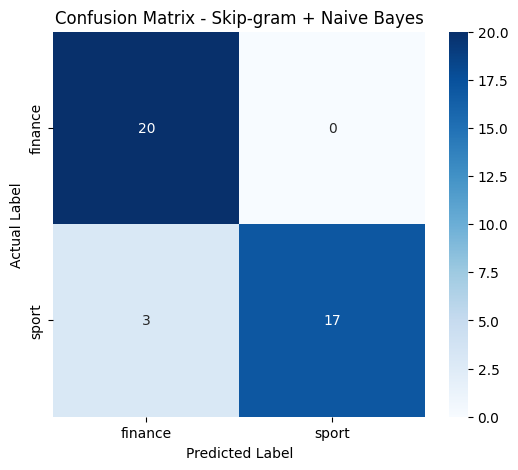

Jumlah prediksi salah: 3


,Data_Testing,Label_Aktual,Label_Prediksi,Status
2,3,1,0,Salah
6,7,1,0,Salah
12,13,1,0,Salah


In [29]:
cm = confusion_matrix(y_test_nb, y_pred, labels=[0, 1])
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["finance", "sport"],
    yticklabels=["finance", "sport"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Skip-gram + Naive Bayes")
plt.show()

df_salah = df_hasil_prediksi[df_hasil_prediksi["Status"] == "Salah"]
print("Jumlah prediksi salah:", len(df_salah))
display(df_salah)

## 29. Ringkasan Evaluasi
Merangkum seluruh metrik evaluasi model (Accuracy, Macro Precision, Macro Recall, Macro F1) ke dalam sebuah tabel ringkasan dan mengekspor hasil prediksi serta ringkasan evaluasi ke file Excel.

In [30]:
df_evaluasi = pd.DataFrame({
    "Model": ["Skip-gram + Naive Bayes"],
    "Jumlah_Training": [len(y_train_nb)],
    "Jumlah_Testing": [len(y_test_nb)],
    "Vector_Size": [VECTOR_SIZE],
    "Window": [WINDOW_SIZE],
    "Accuracy": [accuracy],
    "Precision_Macro": [precision],
    "Recall_Macro": [recall],
    "F1_Macro": [f1]
})
display(df_evaluasi)

df_hasil_prediksi.to_excel("hasil_prediksi_skipgram_naive_bayes.xlsx", index=False)
df_evaluasi.to_excel("evaluasi_skipgram_naive_bayes.xlsx", index=False)
print("Semua hasil berhasil disimpan:")
print("- data_skipgram_training.xlsx")
print("- data_skipgram_testing.xlsx")
print("- hasil_prediksi_skipgram_naive_bayes.xlsx")
print("- evaluasi_skipgram_naive_bayes.xlsx")

,Model,Jumlah_Training,Jumlah_Testing,Vector_Size,Window,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,Skip-gram + Naive Bayes,160,40,50,5,0.925,0.934783,0.925,0.924576


Semua hasil berhasil disimpan:
- data_skipgram_training.xlsx
- data_skipgram_testing.xlsx
- hasil_prediksi_skipgram_naive_bayes.xlsx
- evaluasi_skipgram_naive_bayes.xlsx


## 23. Perbandingan classifier Skip-gram
Document embedding berupa fitur numerik dense. Tiga classifier dibandingkan pada split yang sama.


In [31]:
skipgram_classifiers = {"Skip-gram + Naive Bayes": GaussianNB(), "Skip-gram + Logistic Regression": LogisticRegression(max_iter=2000, random_state=42), "Skip-gram + SVM": LinearSVC(random_state=42)}
hasil_klasifikasi_skipgram = []
for nama, model in skipgram_classifiers.items():
    model.fit(X_train_vectors, y_train.to_numpy())
    prediksi = model.predict(X_test_vectors)
    hasil_klasifikasi_skipgram.append({"Model": nama, "Accuracy": accuracy_score(y_test, prediksi), "Precision_macro": precision_score(y_test, prediksi, average="macro", zero_division=0), "Recall_macro": recall_score(y_test, prediksi, average="macro", zero_division=0), "F1_macro": f1_score(y_test, prediksi, average="macro", zero_division=0)})
hasil_klasifikasi_skipgram = pd.DataFrame(hasil_klasifikasi_skipgram).sort_values("F1_macro", ascending=False)
display(hasil_klasifikasi_skipgram)


d:\data aplikasi\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Skip-gram + Logistic Regression,1.000,1.000000,1.000,1.000000
2,Skip-gram + SVM,1.000,1.000000,1.000,1.000000
0,Skip-gram + Naive Bayes,0.925,0.934783,0.925,0.924576


## 24. Eksperimen vector_size
`vector_size` menentukan jumlah angka yang digunakan untuk merepresentasikan setiap kata. Eksperimen ini melatih model Word2Vec baru untuk setiap ukuran menggunakan **data train saja**, lalu mengubahnya menjadi document embedding dan mengevaluasi classifier.


In [32]:
vector_sizes = [50, 100, 200]
hasil_vector_size = []
for ukuran in vector_sizes:
    model = Word2Vec(
        sentences=train_sentences, vector_size=ukuran, window=WINDOW_SIZE,
        min_count=MIN_COUNT, workers=1, sg=SG, epochs=EPOCHS, seed=SEED
    )
    embedding = model.wv.vectors
    mapping = {word: i for i, word in enumerate(model.wv.index_to_key)}
    train_doc = np.vstack([document_vector(tokens, mapping, embedding, ukuran) for tokens in train_sentences])
    test_doc = np.vstack([document_vector(tokens, mapping, embedding, ukuran) for tokens in test_sentences])
    for nama, classifier in {"Logistic Regression": LogisticRegression(max_iter=2000, random_state=42), "SVM": LinearSVC(random_state=42)}.items():
        classifier.fit(train_doc, y_train.to_numpy())
        prediksi = classifier.predict(test_doc)
        hasil_vector_size.append({"Vector_Size": ukuran, "Classifier": nama, "Accuracy": accuracy_score(y_test, prediksi), "Precision_macro": precision_score(y_test, prediksi, average="macro", zero_division=0), "Recall_macro": recall_score(y_test, prediksi, average="macro", zero_division=0), "F1_macro": f1_score(y_test, prediksi, average="macro", zero_division=0)})
hasil_vector_size = pd.DataFrame(hasil_vector_size).sort_values("F1_macro", ascending=False)
display(hasil_vector_size)


d:\data aplikasi\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\data aplikasi\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\data aplikasi\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


,Vector_Size,Classifier,Accuracy,Precision_macro,Recall_macro,F1_macro
0,50,Logistic Regression,1.0,1.0,1.0,1.0
1,50,SVM,1.0,1.0,1.0,1.0
2,100,Logistic Regression,1.0,1.0,1.0,1.0
3,100,SVM,1.0,1.0,1.0,1.0
4,200,Logistic Regression,1.0,1.0,1.0,1.0
5,200,SVM,1.0,1.0,1.0,1.0


### Interpretasi vector_size
Ukuran vector yang lebih besar dapat menyimpan lebih banyak pola hubungan antarkata, tetapi juga membutuhkan lebih banyak waktu dan data untuk dilatih. Ukuran terbaik dipilih berdasarkan performa pada metrik evaluasi, terutama macro F1, bukan hanya berdasarkan dimensi terbesar.


In [33]:
hasil_klasifikasi_skipgram.to_csv("evaluasi_skipgram_classifier.csv", index=False)
hasil_vector_size.to_csv("eksperimen_vector_size.csv", index=False)
print("Evaluasi classifier disimpan ke evaluasi_skipgram_classifier.csv")
print("Eksperimen vector_size disimpan ke eksperimen_vector_size.csv")


Evaluasi classifier disimpan ke evaluasi_skipgram_classifier.csv
Eksperimen vector_size disimpan ke eksperimen_vector_size.csv


## Audit STEP 1 - Skip-gram / Word2Vec
Audit selesai: split, preprocessing, vocabulary, training, word embedding, document embedding, leakage, dan classifier telah diperiksa. Perbaikan dilakukan bertahap pada bagian berikutnya.
